# Data Structure Mapping


This notebook maps the folder structure with user data for different scenarios.

In [1]:
import io
import json
import os
import re
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
"""
Create and process user data mapping between GDPR exports and scenario folders.

This module creates a DataFrame mapping users to their GDPR data exports and scenario folders.
It includes functions for finding GDPR zip files, checking scenario folders, and listing scenario files.
"""

# Create user DataFrame with scenario, group and bot names
data = {
    'scenario': [
        '15-1', '15-1', '15-2', '15-2', '15-4', '15-4', '15-5', '15-5',
        '16', '16', '18', '18', '22', '22', '23', '23', '24', '24', 
        '28', '28', '29', '29', '33', '33', '34', '34', '35', '35',
        '37', '37', '38', '38', '39', '39', '40', '40', '41', '41',
        '42', '42', '9', '9'
    ],
    'group': [
        'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control',
        'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control',
        'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control', 
        'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control', 'exp', 'control',
        'exp', 'control', 'exp', 'control'
    ],
    'name': [
        'Robert Metzger (Germany)', 'Anthony Diaz', 'Charles Mineau (France)', 'Kenneth Campos',
        'Giorgiana Stoica (Romania)', 'David Bryant',
        'Albert Gunko (UA)', 'Christopher Hale', 'Steven Sherman', 'Jeremy Perry',
        'Matthew Swanson', 'Jamie Rodriguez', 'Jessica Dudley', 'Stephen Dyer',
        'Barbara Martinez', 'Jeanette Mueller', 'Karen Morales', 'Denise Morris',
        'Cynthia Martinez', 'Brandon Miller', 'Tracy Wyatt', 'Brittany Parker',
        'Samantha Espinoza', 'Nicole Miller', 'Rebecca Lester', 'Marissa West',
        'Heidi Bowen', 'Nicole Krause', 'Austin Stewart', 'Robert Perkins',
        'David Simon', 'Rick Meadows', 'Teresa Adkins', 'Cassandra Petersen',
        'Regina Burtor', 'Shelley Cowan', 'Jesse Rodriguez', 'Jesus Simon',
        'Christy Smith', 'Melinda Valenzuela', 'Luis Rodriguez', 'Michal Nguyen'
    ]
}

df = pd.DataFrame(data)
print("Complete dataset:")
display(df)

def get_folder_path(scenario: str, group: str) -> Path:
    """
    Get the folder path for a given scenario and group.
    
    Args:
        scenario: Scenario identifier (e.g. '15-1')
        group: Group type ('exp' or 'control')
        
    Returns:
        Path object for the scenario folder
    """
    base_path = Path('../data')
    folder_name = str(scenario)
    suffix = 'experiment' if group == 'exp' else 'control'
    return base_path / folder_name / f"{scenario}-{suffix}"

df['scenario_folder_path'] = df.apply(lambda row: get_folder_path(row['scenario'], row['group']), axis=1)
print("\nDataset with scenario folder paths:")
display(df)

# List GDPR zip files
gdpr_base_path = Path('gdpr_data')
try:
    gdpr_files = {f.lower(): f for f in os.listdir(gdpr_base_path) if f.lower().endswith('.zip')}
except FileNotFoundError:
    print(f"Warning: GDPR data directory not found at {gdpr_base_path}")
    gdpr_files = {}

def find_gdpr_zip(name: str) -> Path | None:
    """
    Find corresponding GDPR zip file for a given user name.
    
    Args:
        name: User's full name, possibly including country in parentheses
        
    Returns:
        Path to GDPR zip file if found, None otherwise
    """
    if not gdpr_files:
        return None
        
    name_cleaned = re.sub(r'\s*\(.*\)\s*$', '', name).strip()
    parts = name_cleaned.split()
    if not parts:
        return None
        
    first_name, last_name = parts[0], parts[-1]
    
    # Try different filename patterns
    for pattern in [f"{first_name}{last_name}.zip", f"{first_name}_{last_name}.zip", f"{last_name}.zip"]:
        if pattern.lower() in gdpr_files:
            return gdpr_base_path / gdpr_files[pattern.lower()]
            
    print(f"Warning: No GDPR zip found for '{name}' (cleaned: '{name_cleaned}')")
    return None

df['gdpr_zip_path'] = df['name'].apply(find_gdpr_zip)
print("\nDataset with GDPR Zip Paths:")
display(df)

def check_scenario_folders() -> pd.DataFrame:
    """
    Check for missing scenario folders.
    
    Returns:
        DataFrame containing information about missing folders
    """
    missing = []
    for _, row in df.iterrows():
        if not row['scenario_folder_path'].exists():
            missing.append({
                'scenario': row['scenario'],
                'group': row['group'],
                'name': row['name'],
                'path': str(row['scenario_folder_path'])
            })
    return pd.DataFrame(missing)

missing_folders_df = check_scenario_folders()
if not missing_folders_df.empty:
    print("\nMissing base scenario folders:")
    display(missing_folders_df)
else:
    print("\nAll base scenario folders exist!")

def get_scenario_data(scenario: str) -> pd.DataFrame:
    """
    Get data for a specific scenario.
    
    Args:
        scenario: Scenario identifier
        
    Returns:
        DataFrame filtered for the given scenario
    """
    return df[df['scenario'] == str(scenario)]

print("\nData for scenario 42:")
display(get_scenario_data('42'))

def list_scenario_files(scenario: str) -> pd.DataFrame:
    """
    List all run folders for a given scenario.
    
    Args:
        scenario: Scenario identifier
        
    Returns:
        DataFrame containing run folder information
    """
    files_info = []
    for _, row in get_scenario_data(scenario).iterrows():
        if row['scenario_folder_path'].exists():
            try:
                for d in row['scenario_folder_path'].glob('*'):
                    if d.is_dir():
                        files_info.append({
                            'scenario': scenario,
                            'group': row['group'],
                            'name': row['name'],
                            'run_folder': d.name
                        })
            except Exception as e:
                print(f"Error listing files in {row['scenario_folder_path']}: {e}")
    return pd.DataFrame(files_info)

print("\nRun folders in scenario 42:")
display(list_scenario_files('42'))

Complete dataset:


,scenario,group,name
0,15-1,exp,Robert Metzger (Germany)
1,15-1,control,Anthony Diaz
2,15-2,exp,Charles Mineau (France)
3,15-2,control,Kenneth Campos
4,15-4,exp,Giorgiana Stoica (Romania)
5,15-4,control,David Bryant
6,15-5,exp,Albert Gunko (UA)
7,15-5,control,Christopher Hale
8,16,exp,Steven Sherman
9,16,control,Jeremy Perry



Dataset with scenario folder paths:


,scenario,group,name,scenario_folder_path
0,15-1,exp,Robert Metzger (Germany),..\data\15-1\15-1-experiment
1,15-1,control,Anthony Diaz,..\data\15-1\15-1-control
2,15-2,exp,Charles Mineau (France),..\data\15-2\15-2-experiment
3,15-2,control,Kenneth Campos,..\data\15-2\15-2-control
4,15-4,exp,Giorgiana Stoica (Romania),..\data\15-4\15-4-experiment
5,15-4,control,David Bryant,..\data\15-4\15-4-control
6,15-5,exp,Albert Gunko (UA),..\data\15-5\15-5-experiment
7,15-5,control,Christopher Hale,..\data\15-5\15-5-control
8,16,exp,Steven Sherman,..\data\16\16-experiment
9,16,control,Jeremy Perry,..\data\16\16-control



Dataset with GDPR Zip Paths:


,scenario,group,name,scenario_folder_path,gdpr_zip_path
0,15-1,exp,Robert Metzger (Germany),..\data\15-1\15-1-experiment,gdpr_data\RobertMetzger.zip
1,15-1,control,Anthony Diaz,..\data\15-1\15-1-control,gdpr_data\AnthonyDiaz.zip
2,15-2,exp,Charles Mineau (France),..\data\15-2\15-2-experiment,gdpr_data\CharlesMineau.zip
3,15-2,control,Kenneth Campos,..\data\15-2\15-2-control,gdpr_data\KennethCampos.zip
4,15-4,exp,Giorgiana Stoica (Romania),..\data\15-4\15-4-experiment,gdpr_data\GiorgianaStoica.zip
5,15-4,control,David Bryant,..\data\15-4\15-4-control,gdpr_data\DavidBryant.zip
6,15-5,exp,Albert Gunko (UA),..\data\15-5\15-5-experiment,gdpr_data\AlbertGunko.zip
7,15-5,control,Christopher Hale,..\data\15-5\15-5-control,gdpr_data\ChristopherHale.zip
8,16,exp,Steven Sherman,..\data\16\16-experiment,gdpr_data\StevenSherman.zip
9,16,control,Jeremy Perry,..\data\16\16-control,gdpr_data\JeremyPerry.zip



All base scenario folders exist!

Data for scenario 42:


,scenario,group,name,scenario_folder_path,gdpr_zip_path
38,42,exp,Christy Smith,..\data\42\42-experiment,gdpr_data\ChristySmith.zip
39,42,control,Melinda Valenzuela,..\data\42\42-control,gdpr_data\MelindaValenzuela.zip



Run folders in scenario 42:


,scenario,group,name,run_folder
0,42,exp,Christy Smith,1
1,42,exp,Christy Smith,2
2,42,exp,Christy Smith,3
3,42,exp,Christy Smith,4
4,42,control,Melinda Valenzuela,1
5,42,control,Melinda Valenzuela,2
6,42,control,Melinda Valenzuela,3
7,42,control,Melinda Valenzuela,4


In [3]:
def get_scenario_video_ids(scenario_folder_path: Path) -> set[str]:
    """
    Extract video IDs from scenario response files.

    Args:
        scenario_folder_path: Path to the scenario folder containing run folders

    Returns:
        Set of video IDs found in the scenario responses
    """
    video_ids = set()
    if scenario_folder_path is None or not scenario_folder_path.exists():
        return video_ids

    run_folders = [d for d in scenario_folder_path.iterdir() 
                  if d.is_dir() and d.name.isdigit()]

    for run_folder in run_folders:
        responses_path = run_folder / 'responses'
        if not (responses_path.exists() and responses_path.is_dir()):
            continue
            
        response_files = [f for f in responses_path.glob('*.json') 
                         if f.name.lower() != 'config.json']
        
        for file_path in response_files:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                for video in data.get('itemList', []):
                    if isinstance(video, dict):
                        video_id = video.get("id")
                        if video_id:
                            video_ids.add(str(video_id))
    return video_ids


def get_gdpr_post_ids(zip_path: Path) -> set[str]:
    """
    Extract post IDs from a GDPR data export zip file.

    Args:
        zip_path: Path to the GDPR zip file

    Returns:
        Set of post IDs found in the GDPR data
    """
    post_ids = set()
    if zip_path is None or not zip_path.exists():
        return post_ids

    with zipfile.ZipFile(zip_path, 'r') as z:
        # Find the user data JSON file
        json_filename = next(
            (name for name in z.namelist() 
             if 'user_data_tiktok' in name.lower() and name.lower().endswith('.json')),
            None
        )
        
        if not json_filename:
            print(f"Warning: 'user_data_tiktok.json' not found in {zip_path.name}")
            return post_ids

        with z.open(json_filename) as f:
            data = json.load(f)
            history_list = None

            # Handle different GDPR data structures
            if 'Your Activity' in data and isinstance(data['Your Activity'], dict):
                watch_history = data['Your Activity'].get('Watch History', {})
                if isinstance(watch_history, dict):
                    history_list = watch_history.get('VideoList')
            elif 'Activity' in data and 'Video Browsing History' in data['Activity']:
                browsing_history = data['Activity']['Video Browsing History']
                if isinstance(browsing_history, dict):
                    history_list = browsing_history.get('VideoList')
                elif isinstance(browsing_history, list):
                    history_list = browsing_history
            elif 'Video Browsing History' in data:
                browsing_history = data['Video Browsing History']
                if isinstance(browsing_history, dict):
                    history_list = browsing_history.get('VideoList')
                elif isinstance(browsing_history, list):
                    history_list = browsing_history

            if history_list and isinstance(history_list, list):
                for item in history_list:
                    video_link = None
                    if isinstance(item, dict):
                        video_link = (item.get('Link') or 
                                    item.get('VideoLink') or 
                                    (item.get('Item', {}).get('Link')))
                        
                        if (video_link and isinstance(video_link, str) and
                            ('tiktok.com' in video_link or 'tiktokv.com' in video_link) and
                            ('/video/' in video_link or '/share/video/' in video_link)):
                            
                            if '/video/' in video_link:
                                post_id = video_link.split('/video/')[1].split('?')[0].split('/')[0]
                            else:
                                post_id = video_link.split('/share/video/')[1].split('?')[0].split('/')[0]

                            if post_id and post_id.isdigit():
                                post_ids.add(post_id)
            else:
                if 'Your Activity' in data and 'Watch History' in data.get('Your Activity', {}):
                    actual_value = data['Your Activity']['Watch History'].get('VideoList')
                    print(f"Warning: 'VideoList' is null or not a list in {zip_path.name} / "
                          f"{json_filename}. Value: {type(actual_value)}")
                else:
                    print(f"Warning: Could not find 'Your Activity -> Watch History -> VideoList' "
                          f"in {zip_path.name} / {json_filename}")
    return post_ids


# Process all users and collect results
results = []
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Processing Users"):
    scenario = row['scenario']
    group = row['group']
    name = row['name']
    scenario_path = row['scenario_folder_path']
    gdpr_path = row['gdpr_zip_path']
    
    gdpr_ids = get_gdpr_post_ids(gdpr_path)
    scenario_ids = get_scenario_video_ids(scenario_path)
    
    match_count = len(gdpr_ids.intersection(scenario_ids))
    gdpr_count = len(gdpr_ids)
    scenario_count = len(scenario_ids)
    percentage = (match_count / gdpr_count) * 100 if gdpr_count > 0 else 0.0
    
    results.append({
        'scenario': scenario,
        'group': group,
        'name': name,
        'gdpr_zip_path': gdpr_path,
        'scenario_folder_path': scenario_path,
        'gdpr_post_count': gdpr_count,
        'scenario_video_count': scenario_count,
        'match_count': match_count,
        'match_percentage': round(percentage, 2)
    })

results_df = pd.DataFrame(results)
print("\n--- Comparison Results ---")
display(results_df)
print("\n--- Users potentially missing data ---")
display(results_df[(results_df['gdpr_post_count'] == 0) | 
                   (results_df['scenario_video_count'] == 0)])

Processing Users:   0%|          | 0/42 [00:00<?, ?it/s]


--- Comparison Results ---


,scenario,group,name,gdpr_zip_path,scenario_folder_path,gdpr_post_count,scenario_video_count,match_count,match_percentage
0,15-1,exp,Robert Metzger (Germany),gdpr_data\RobertMetzger.zip,..\data\15-1\15-1-experiment,3,614,0,0.00
1,15-1,control,Anthony Diaz,gdpr_data\AnthonyDiaz.zip,..\data\15-1\15-1-control,1015,1037,1007,99.21
2,15-2,exp,Charles Mineau (France),gdpr_data\CharlesMineau.zip,..\data\15-2\15-2-experiment,1106,1106,1099,99.37
3,15-2,control,Kenneth Campos,gdpr_data\KennethCampos.zip,..\data\15-2\15-2-control,1107,1099,1087,98.19
4,15-4,exp,Giorgiana Stoica (Romania),gdpr_data\GiorgianaStoica.zip,..\data\15-4\15-4-experiment,970,986,962,99.18
5,15-4,control,David Bryant,gdpr_data\DavidBryant.zip,..\data\15-4\15-4-control,1023,879,783,76.54
6,15-5,exp,Albert Gunko (UA),gdpr_data\AlbertGunko.zip,..\data\15-5\15-5-experiment,1004,1009,994,99.00
7,15-5,control,Christopher Hale,gdpr_data\ChristopherHale.zip,..\data\15-5\15-5-control,911,964,906,99.45
8,16,exp,Steven Sherman,gdpr_data\StevenSherman.zip,..\data\16\16-experiment,992,1189,970,97.78
9,16,control,Jeremy Perry,gdpr_data\JeremyPerry.zip,..\data\16\16-control,1034,1102,1028,99.42



--- Users potentially missing data ---


,scenario,group,name,gdpr_zip_path,scenario_folder_path,gdpr_post_count,scenario_video_count,match_count,match_percentage


In [4]:
# Display current results
print("Existing results_df head:")
display(results_df.head())

# Define ban status data for all bots
ban_data = {
    "15-1": {
        "exp": {"name": "Robert Metzger (Germany)", "data_retrieved": True, "banned_before": "Yes", "banned_after": "Yes"},
        "control": {"name": "Anthony Diaz", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "15-2": {
        "exp": {"name": "Charles Mineau (France)", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Kenneth Campos", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "15-3": {
        "exp": {"name": "Sabrina Fallaci (Italy)", "data_retrieved": False, "banned_before": "Yes", "banned_after": "Yes"},
        "control": {"name": "William Zuniga", "data_retrieved": False, "banned_before": "N/A", "banned_after": "N/A"}
    },
    "15-4": {
        "exp": {"name": "Giorgiana Stoica (Romania)", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "David Bryant", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "15-5": {
        "exp": {"name": "Albert Gunko (UA)", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Christopher Hale", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "16": {
        "exp": {"name": "Steven Sherman", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Jeremy Perry", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "18": {
        "exp": {"name": "Matthew Swanson", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Jamie Rodriguez", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "22": {
        "exp": {"name": "Jessica Dudley", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Stephen Dyer", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "23": {
        "exp": {"name": "Barbara Martinez", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Jeanette Mueller", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "24": {
        "exp": {"name": "Karen Morales", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Denise Morris", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "28": {
        "exp": {"name": "Cynthia Martinez", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Brandon Miller", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "29": {
        "exp": {"name": "Tracy Wyatt", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Brittany Parker", "data_retrieved": True, "banned_before": "Yes", "banned_after": "Yes"}
    },
    "33": {
        "exp": {"name": "Samantha Espinoza", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Nicole Miller", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"}
    },
    "34": {
        "exp": {"name": "Rebecca Lester", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Marissa West", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"}
    },
    "35": {
        "exp": {"name": "Heidi Bowen", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Nicole Krause", "data_retrieved": True, "banned_before": "Yes", "banned_after": "Yes"}
    },
    "37": {
        "exp": {"name": "Austin Stewart", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Robert Perkins", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"}
    },
    "38": {
        "exp": {"name": "David Simon", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Rick Meadows", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"}
    },
    "39": {
        "exp": {"name": "Teresa Adkins", "data_retrieved": True, "banned_before": "Yes", "banned_after": "Yes"},
        "control": {"name": "Cassandra Petersen", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"}
    },
    "40": {
        "exp": {"name": "Regina Burtor", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Shelley Cowan", "data_retrieved": True, "banned_before": "Yes", "banned_after": "Yes"}
    },
    "41": {
        "exp": {"name": "Jesse Rodriguez", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Jesus Simon", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    },
    "42": {
        "exp": {"name": "Christy Smith", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"},
        "control": {"name": "Melinda Valenzuela", "data_retrieved": True, "banned_before": "No", "banned_after": "Yes"}
    },
    "9": {
        "exp": {"name": "Luis Rodriguez", "data_retrieved": True, "banned_before": "No", "banned_after": "No"},
        "control": {"name": "Michal Nguyen", "data_retrieved": True, "banned_before": "No", "banned_after": "No"}
    }
}

def create_ban_info_dataframe(ban_data: dict) -> pd.DataFrame:
    """
    Create a DataFrame containing ban information for all participants.
    
    Args:
        ban_data: Dictionary containing ban status data for each participant
        
    Returns:
        pd.DataFrame: DataFrame with ban information including scenario, group, name,
                     data retrieval status, and ban status before/after study
    """
    ban_records = [
        {
            'scenario': scenario,
            'group': group_type,
            'name': details['name'],
            'data_retrieved': details['data_retrieved'],
            'banned_before': details['banned_before'],
            'banned_after': details['banned_after']
        }
        for scenario, groups in ban_data.items()
        for group_type, details in groups.items()
    ]
    
    # Create and clean DataFrame
    ban_info_df = pd.DataFrame(ban_records)
    ban_info_df['scenario'] = ban_info_df['scenario'].astype(str).str.strip()
    ban_info_df['group'] = ban_info_df['group'].astype(str).str.strip()
    ban_info_df['banned_before'] = ban_info_df['banned_before'].astype(str).str.strip()
    ban_info_df['banned_after'] = ban_info_df['banned_after'].astype(str).str.strip()
    
    return ban_info_df

def merge_results_with_ban_info(results_df: pd.DataFrame, ban_info_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge results DataFrame with ban information.
    
    Args:
        results_df: DataFrame containing analysis results
        ban_info_df: DataFrame containing ban status information
        
    Returns:
        pd.DataFrame: Merged DataFrame with analysis results and ban information
    """
    results_df['scenario'] = results_df['scenario'].astype(str)
    results_df['group'] = results_df['group'].astype(str)
    
    return pd.merge(
        results_df,
        ban_info_df[['scenario', 'group', 'banned_before', 'banned_after']],
        on=['scenario', 'group'],
        how='left'
    )

# Create ban info DataFrame
ban_info_df = create_ban_info_dataframe(ban_data)

print("\nParsed Ban Info DataFrame:")
display(ban_info_df.head())
print(f"Ban Info Shape: {ban_info_df.shape}")

# Merge results with ban info
final_df = merge_results_with_ban_info(results_df, ban_info_df)

print("\nFinal Merged DataFrame (with Ban Info):")
display(final_df.head())
print(f"Final DataFrame Shape: {final_df.shape}")


Existing results_df head:


,scenario,group,name,gdpr_zip_path,scenario_folder_path,gdpr_post_count,scenario_video_count,match_count,match_percentage
0,15-1,exp,Robert Metzger (Germany),gdpr_data\RobertMetzger.zip,..\data\15-1\15-1-experiment,3,614,0,0.00
1,15-1,control,Anthony Diaz,gdpr_data\AnthonyDiaz.zip,..\data\15-1\15-1-control,1015,1037,1007,99.21
2,15-2,exp,Charles Mineau (France),gdpr_data\CharlesMineau.zip,..\data\15-2\15-2-experiment,1106,1106,1099,99.37
3,15-2,control,Kenneth Campos,gdpr_data\KennethCampos.zip,..\data\15-2\15-2-control,1107,1099,1087,98.19
4,15-4,exp,Giorgiana Stoica (Romania),gdpr_data\GiorgianaStoica.zip,..\data\15-4\15-4-experiment,970,986,962,99.18



Parsed Ban Info DataFrame:


,scenario,group,name,data_retrieved,banned_before,banned_after
0,15-1,exp,Robert Metzger (Germany),True,Yes,Yes
1,15-1,control,Anthony Diaz,True,No,No
2,15-2,exp,Charles Mineau (France),True,No,Yes
3,15-2,control,Kenneth Campos,True,No,No
4,15-3,exp,Sabrina Fallaci (Italy),False,Yes,Yes


Ban Info Shape: (44, 6)

Final Merged DataFrame (with Ban Info):


,scenario,group,name,gdpr_zip_path,scenario_folder_path,gdpr_post_count,scenario_video_count,match_count,match_percentage,banned_before,banned_after
0,15-1,exp,Robert Metzger (Germany),gdpr_data\RobertMetzger.zip,..\data\15-1\15-1-experiment,3,614,0,0.00,Yes,Yes
1,15-1,control,Anthony Diaz,gdpr_data\AnthonyDiaz.zip,..\data\15-1\15-1-control,1015,1037,1007,99.21,No,No
2,15-2,exp,Charles Mineau (France),gdpr_data\CharlesMineau.zip,..\data\15-2\15-2-experiment,1106,1106,1099,99.37,No,Yes
3,15-2,control,Kenneth Campos,gdpr_data\KennethCampos.zip,..\data\15-2\15-2-control,1107,1099,1087,98.19,No,No
4,15-4,exp,Giorgiana Stoica (Romania),gdpr_data\GiorgianaStoica.zip,..\data\15-4\15-4-experiment,970,986,962,99.18,No,Yes


Final DataFrame Shape: (42, 11)


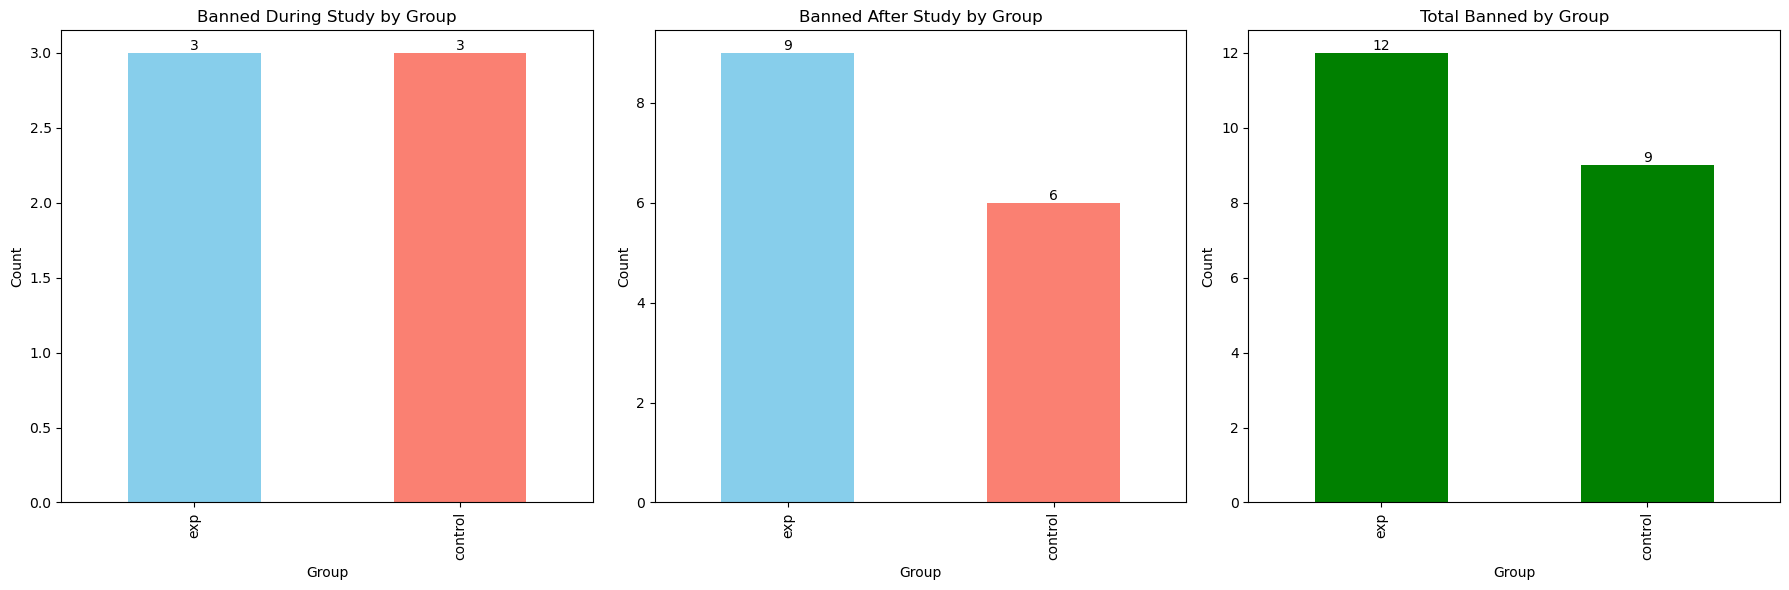

In [5]:
def create_ban_masks(ban_info_df: pd.DataFrame) -> tuple[pd.Series, pd.Series, pd.Series]:
    """
    Create boolean masks for different ban statuses.
    
    Args:
        ban_info_df: DataFrame containing ban information
        
    Returns:
        tuple containing:
            - mask for users banned during study
            - mask for users banned after study
            - mask for users banned after study (excluding those banned during)
    """
    banned_during_mask = ban_info_df['banned_before'].str.strip().str.lower() == 'yes'
    banned_after_mask = ban_info_df['banned_after'].str.strip().str.lower() == 'yes'
    banned_after_exclusive_mask = banned_after_mask & (~banned_during_mask)
    
    return banned_during_mask, banned_after_mask, banned_after_exclusive_mask

def compute_ban_counts(ban_info_df: pd.DataFrame, masks: tuple[pd.Series, pd.Series, pd.Series]) -> tuple[pd.Series, pd.Series, pd.Series]:
    """
    Compute ban counts per group using the provided masks.
    
    Args:
        ban_info_df: DataFrame containing ban information
        masks: Tuple of boolean masks from create_ban_masks()
        
    Returns:
        tuple containing:
            - counts of users banned during study by group
            - counts of users banned after study by group (exclusive)
            - total banned counts by group
    """
    banned_during_mask, _, banned_after_exclusive_mask = masks
    
    banned_during_counts = ban_info_df[banned_during_mask]['group'].value_counts()
    banned_after_exclusive_counts = ban_info_df[banned_after_exclusive_mask]['group'].value_counts()
    total_banned_counts = banned_during_counts.add(banned_after_exclusive_counts, fill_value=0)
    
    return banned_during_counts, banned_after_exclusive_counts, total_banned_counts

def plot_ban_statistics(counts: tuple[pd.Series, pd.Series, pd.Series]) -> None:
    """
    Create three side-by-side bar plots showing ban statistics and save to plots folder.
    
    Args:
        counts: Tuple of Series containing ban counts from compute_ban_counts()
    """
    banned_during_counts, banned_after_exclusive_counts, total_banned_counts = counts
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot banned during study
    banned_during_counts.plot(kind='bar', ax=ax[0], color=['skyblue', 'salmon'])
    ax[0].set_title("Banned During Study by Group")
    ax[0].set_xlabel("Group")
    ax[0].set_ylabel("Count")
    for p in ax[0].patches:
        ax[0].annotate(str(int(p.get_height())), 
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')
    
    # Plot banned after study
    banned_after_exclusive_counts.plot(kind='bar', ax=ax[1], color=['skyblue', 'salmon'])
    ax[1].set_title("Banned After Study by Group")
    ax[1].set_xlabel("Group") 
    ax[1].set_ylabel("Count")
    for p in ax[1].patches:
        ax[1].annotate(str(int(p.get_height())),
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')
    
    # Plot total banned
    total_banned_counts.plot(kind='bar', ax=ax[2], color=['green'])
    ax[2].set_title("Total Banned by Group")
    ax[2].set_xlabel("Group")
    ax[2].set_ylabel("Count")
    for p in ax[2].patches:
        ax[2].annotate(str(int(p.get_height())),
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')
    
    plt.tight_layout()
    
    # Create plots directory if it doesn't exist
    os.makedirs('plots', exist_ok=True)
    
    # Save figure
    plt.savefig('plots/ban_statistics.png')
    plt.show()

# Define scenario categories
scenario_categories = {
    'location': ['15-1', '15-2', '15-3', '15-4', '15-5'],
    'random explicit': ['18', '29'],
    'defined explicit': ['24'],
    'random implicit': ['18', '33'],
    'defined implicit': ['38', '5']
}

# Create masks and compute counts
masks = create_ban_masks(ban_info_df)
counts = compute_ban_counts(ban_info_df, masks)

# Generate plots
plot_ban_statistics(counts)

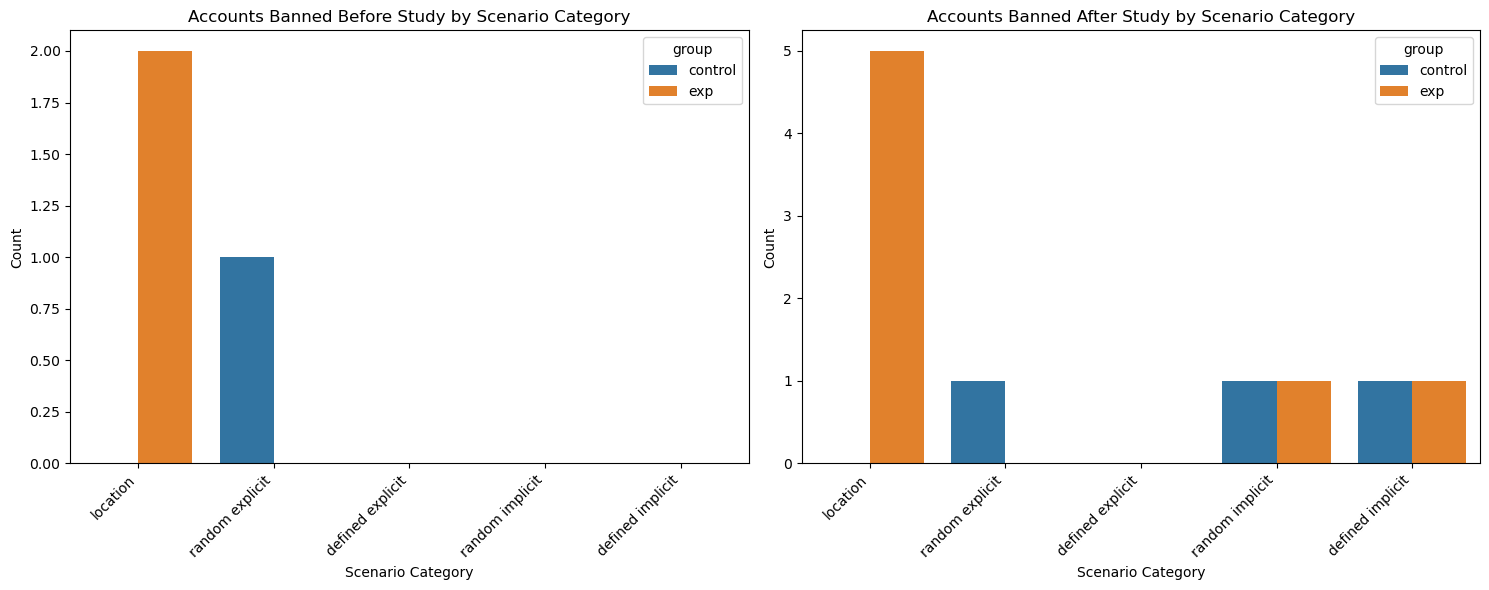

In [6]:
def generate_ban_data(ban_info_df: pd.DataFrame, scenario_categories: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generate DataFrames containing ban statistics before and after the study.
    
    Args:
        ban_info_df: DataFrame containing ban information
        scenario_categories: Dict mapping category names to lists of scenario IDs
        
    Returns:
        Tuple of (before_bans_df, after_bans_df) containing ban counts by category and group
    """
    data_before = []  # Data list for banned before counts
    data_after = []   # Data list for banned after counts

    # Loop over each scenario category and both groups: control and experiment
    for category, scenarios in scenario_categories.items():
        subset = ban_info_df[ban_info_df['scenario'].isin(scenarios)]
        for grp in ['control', 'exp']:
            count_before = subset[
                (subset['group'] == grp) &
                (subset['banned_before'].str.strip().str.lower() == 'yes')
            ].shape[0]
            count_after = subset[
                (subset['group'] == grp) &
                (subset['banned_after'].str.strip().str.lower() == 'yes')
            ].shape[0]
            data_before.append({'category': category, 'group': grp, 'count': count_before})
            data_after.append({'category': category, 'group': grp, 'count': count_after})

    return pd.DataFrame(data_before), pd.DataFrame(data_after)

def plot_ban_statistics(df_before: pd.DataFrame, df_after: pd.DataFrame) -> None:
    """
    Plot ban statistics before and after study by scenario category.
    
    Args:
        df_before: DataFrame containing ban counts before study
        df_after: DataFrame containing ban counts after study
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Bar chart for accounts banned before the study
    sns.barplot(data=df_before, x='category', y='count', hue='group', ax=ax[0])
    ax[0].set_title("Accounts Banned Before Study by Scenario Category")
    ax[0].set_xlabel("Scenario Category")
    ax[0].set_ylabel("Count")
    ax[0].xaxis.set_major_locator(ticker.FixedLocator(ax[0].get_xticks()))
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')

    # Bar chart for accounts banned after the study
    sns.barplot(data=df_after, x='category', y='count', hue='group', ax=ax[1])
    ax[1].set_title("Accounts Banned After Study by Scenario Category")
    ax[1].set_xlabel("Scenario Category")
    ax[1].set_ylabel("Count")
    ax[1].xaxis.set_major_locator(ticker.FixedLocator(ax[1].get_xticks()))
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('plots/banned_accounts_by_scenario.png')
    plt.show()

# Generate ban statistics and plot
df_before, df_after = generate_ban_data(ban_info_df, scenario_categories)
plot_ban_statistics(df_before, df_after)

In [7]:
# Account mapping for checking likes and following data
like_check_accounts = {
    '22': 'Jessica Dudley',
    '23': 'Barbara Martinez', 
    '18': 'Matthew Swanson',
    '16': 'Steven Sherman'
}

following_check_accounts = {
    '28': 'Cynthia Martinez',
    '29': 'Tracy Wyatt'
}

def analyze_account_data(account_name: str, check_type: str = 'likes') -> None:
    """
    Analyze TikTok account data from GDPR export for likes or following information.

    Args:
        account_name: Name of the account to analyze
        check_type: Type of analysis to perform - 'likes' or 'following'

    Prints:
        Account details including total counts and individual records for either:
        - Likes: Date and link for each liked post
        - Following: Username and follow date for each followed account
    
    Raises:
        Exception: If there are issues reading or processing the GDPR data file
    """
    file_path = Path(r"gdpr_data") / f"{account_name.replace(' ', '')}.zip"
    
    try:
        with zipfile.ZipFile(file_path, 'r') as z:
            # Find the user data JSON file
            json_file = next(f for f in z.namelist() if 'user_data_tiktok' in f.lower())
            with z.open(json_file) as f:
                data = json.load(f)
                
                if check_type == 'likes':
                    # Process like list data
                    like_section = data.get('Your Activity', {}).get('Like List', {})
                    item_favorite_list = like_section.get('ItemFavoriteList')
                    
                    print(f"\nAccount: {account_name}")
                    if item_favorite_list is not None:
                        print(f"Total likes: {len(item_favorite_list)}")
                        print("Like Details:")
                        for like in item_favorite_list:
                            if isinstance(like, dict):
                                print(f"Date: {like.get('Date', 'N/A')}")
                                print(f"Link: {like.get('Link', 'N/A')}")
                                print("-" * 50)
                    else:
                        print("No like list data found (ItemFavoriteList is null).")
                
                elif check_type == 'following':
                    # Process following list data
                    following_section = data.get('Your Activity', {}).get('Following', {})
                    following_list = following_section.get('Following')
                    
                    print(f"\nAccount: {account_name}")
                    if following_list is not None:
                        print(f"Total following: {len(following_list)}")
                        print("Following Details:")
                        for follow in following_list:
                            if isinstance(follow, dict):
                                print(f"Username: {follow.get('Username', 'N/A')}")
                                print(f"Date: {follow.get('Date', 'N/A')}")
                                print("-" * 50)
                    else:
                        print("No following data found (Following is null).")
    
    except Exception as e:
        print(f"Error processing {account_name}: {str(e)}")

# Analyze like data for specified accounts
print("=== LIKE LIST ANALYSIS ===")
for scenario, account in like_check_accounts.items():
    print(f"\nChecking Scenario {scenario}")
    analyze_account_data(account, 'likes')

# Analyze following data for specified accounts  
print("\n=== FOLLOWING ANALYSIS ===")
for scenario, account in following_check_accounts.items():
    print(f"\nChecking Scenario {scenario}")
    analyze_account_data(account, 'following')

=== LIKE LIST ANALYSIS ===

Checking Scenario 22

Account: Jessica Dudley
No like list data found (ItemFavoriteList is null).

Checking Scenario 23

Account: Barbara Martinez
No like list data found (ItemFavoriteList is null).

Checking Scenario 18

Account: Matthew Swanson
No like list data found (ItemFavoriteList is null).

Checking Scenario 16

Account: Steven Sherman
No like list data found (ItemFavoriteList is null).

=== FOLLOWING ANALYSIS ===

Checking Scenario 28

Account: Cynthia Martinez
No following data found (Following is null).

Checking Scenario 29

Account: Tracy Wyatt
Total following: 1
Following Details:
Username: N/A
Date: 2025-02-03 10:06:40
--------------------------------------------------
